# Практика 19. Класифікація математичних моделей: аналіз прикладів, перевірка адекватності моделі

**Варіант 1: Київ**

Мета: класифікувати модель прогнозу місячного споживання електроенергії, підібрати просту лінійну залежність і перевірити її адекватність через R² та структуру залишків.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variant = 1
city = 'Київ'
base_temp = 9.5
amplitude = 14.0
base_consumption = 200.0
k = 55.0
noise_sd = 80.0

np.random.seed(variant)
months = np.arange(1, 13)
temp = base_temp + amplitude * np.cos((months - 7) / 12 * 2 * np.pi)
temp = np.round(temp + np.random.normal(0, 0.5, size=12), 1)
consumption = base_consumption - k * (temp - base_temp) + np.random.normal(0, noise_sd, size=12)
consumption = np.round(consumption, 0)

city_data = pd.DataFrame({
    'місяць': months,
    'температура': temp,
    'споживання_МВтгод': consumption,
})
print(f'Варіант {variant}: {city}')
print(city_data)

Варіант 1: Київ
    місяць  температура  споживання_МВтгод
0        1         -3.7              900.0
1        2         -2.9              851.0
2        3          2.2              692.0
3        4          9.0              140.0
4        5         16.9             -221.0
5        6         20.5             -475.0
6        7         24.4             -616.0
7        8         21.2             -397.0
8        9         16.7             -284.0
9       10          9.4              297.0
10      11          3.2              619.0
11      12         -3.7              966.0


## Побудова набору `city_data`

Варіант 1 — Київ: `base_temp = 9.5 °C`, `amplitude = 14 °C`, базове споживання `200 МВт·год`, `k = 55`, `noise_sd = 80`. Використано `seed=1`.

## Завдання 1. Класифікація сценарію

- **Стохастична:** формула має детерміновану середню частину, але споживання містить випадковий шум `noise_sd`, тому модель у цілому стохастична.
- **Не балансова, не оптимізаційна, не імітаційна:** вона не описує закон збереження, не шукає найкраще рішення і не моделює покрокову еволюцію системи.
- **Статична:** прогноз конкретного місяця залежить від температури цього місяця, а не від споживання попереднього місяця.
- Отже, це описова/прогнозна статистична модель, а не динамічна симуляція.

In [2]:
slope, intercept = np.polyfit(city_data['температура'], city_data['споживання_МВтгод'], 1)
print(f'споживання ≈ {intercept:.1f} + ({slope:.1f}) · температура')
print(f'Знак нахилу: {"від\'ємний" if slope < 0 else "додатний"}')

споживання ≈ 739.1 + (-56.5) · температура
Знак нахилу: від'ємний


## Завдання 2. Побудова моделі на власних даних

Підбираємо модель `споживання = a + b · температура`. Через знак `b` перевіряємо, чи підтверджують дані очікування: холодніші місяці мають більше споживання на опалення.

    місяць  температура  споживання_МВтгод  передбачення  залишок
0        1         -3.7              900.0        948.25   -48.25
1        2         -2.9              851.0        903.04   -52.04
2        3          2.2              692.0        614.80    77.20
3        4          9.0              140.0        230.49   -90.49
4        5         16.9             -221.0       -215.99    -5.01
5        6         20.5             -475.0       -419.45   -55.55
6        7         24.4             -616.0       -639.86    23.86
7        8         21.2             -397.0       -459.01    62.01
8        9         16.7             -284.0       -204.69   -79.31
9       10          9.4              297.0        207.88    89.12
10      11          3.2              619.0        558.29    60.71
11      12         -3.7              966.0        948.25    17.75
R² = 0.9882


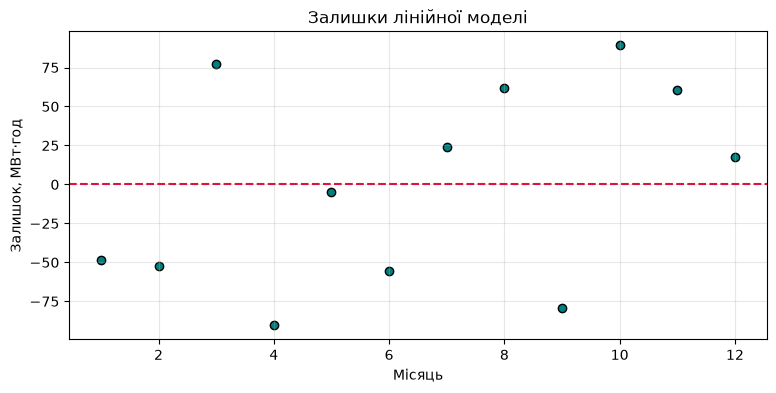

Оцінка: перевіряємо, чи немає систематичного тренду залишків за місяцями.


In [3]:
city_data['передбачення'] = intercept + slope * city_data['температура']
city_data['залишок'] = city_data['споживання_МВтгод'] - city_data['передбачення']
ss_res = (city_data['залишок'] ** 2).sum()
ss_tot = ((city_data['споживання_МВтгод'] - city_data['споживання_МВтгод'].mean()) ** 2).sum()
r_squared = 1 - ss_res / ss_tot

print(city_data[['місяць', 'температура', 'споживання_МВтгод', 'передбачення', 'залишок']].round(2))
print(f'R² = {r_squared:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.axhline(0, color='crimson', linestyle='--')
ax.scatter(city_data['місяць'], city_data['залишок'], color='teal', edgecolor='black')
ax.set_xlabel('Місяць')
ax.set_ylabel('Залишок, МВт·год')
ax.set_title('Залишки лінійної моделі')
ax.grid(alpha=0.3)
plt.show()
print('Оцінка: перевіряємо, чи немає систематичного тренду залишків за місяцями.')

## Завдання 3. Залишки й оцінка адекватності

Обчислюємо залишки `спостережено - передбачено`, R² і будуємо графік залишків проти місяця. Оцінюємо не лише величину помилок, а й наявність систематичної структури.

In [4]:
first_temperature = city_data.loc[0, 'температура']
first_prediction_manual = intercept + slope * first_temperature
first_prediction_code = city_data.loc[0, 'передбачення']
print(f'Перший місяць: T = {first_temperature:.1f} °C')
print(f'Ручний прогноз = {first_prediction_manual:.4f}')
print(f'Програмний прогноз = {first_prediction_code:.4f}')
print(f'Верифікація пройдена? {np.isclose(first_prediction_manual, first_prediction_code)}')
print('Валідація потребувала б нових спостережень, наприклад даних наступного року.')

Перший місяць: T = -3.7 °C
Ручний прогноз = 948.2494
Програмний прогноз = 948.2494
Верифікація пройдена? True
Валідація потребувала б нових спостережень, наприклад даних наступного року.


## Завдання 4. Верифікація і валідація

**Верифікація:** перевіряємо, що код правильно реалізує лінійну формулу, а ручний розрахунок для першого місяця збігається з програмним передбаченням.

**Валідація:** порівнюємо передбачення з незалежними спостереженнями, наприклад даними наступного року. Ті самі 12 точок, на яких оцінено `a` і `b`, показують підгонку, але не дають чесної перевірки узагальнення.

## Завдання 5. Пропозиція вдосконалення моделі

Якщо залишки мають сезонну структуру або різняться між холодними й теплими місяцями, доцільно додати нелінійний член `температура²` або окремий сезонний індикатор. Це ускладнення прямо відповідає типу побаченої розбіжності, але його слід перевірити на нових даних, щоб не підлаштуватися до випадкового шуму.

## Контрольні питання

**1. Верифікація і валідація.** Верифікація перевіряє правильність реалізації коду: чи формула `a + b · температура` обчислюється без помилки та чи збігається ручний прогноз для конкретного місяця. Валідація перевіряє, наскільки ця правильно реалізована модель відповідає реальному споживанню; для чесної оцінки потрібні нові дані, не використані при підборі.

**2. Незалежні ознаки класифікації.** Стохастичність описує наявність випадкового шуму, статичність — залежність прогнозу лише від поточного входу, а описово-прогнозний статус — мету й структуру моделі. Це різні питання, тому ознаки не суперечать одна одній.

**3. Значення R².** Воно показує частку розкиду споживання, пояснену температурою в цій вибірці. Високе R² не доводить правильність моделі й не гарантує надійної екстраполяції поза спостереженим діапазоном.

**4. Чому залишки важливіші за одне число?** Систематичний тренд залишків показує пропущену закономірність, навіть якщо сумарна помилка або R² виглядають прийнятно. Випадковий розкид навколо нуля є сильнішою ознакою адекватності лінійної форми.

## Підсумок

- Сценарій класифіковано як стохастичний, статичний і описово-прогнозний.
- Лінійну модель підібрано на власному варіанті Києва.
- Адекватність оцінено і через R², і через структуру залишків.
- Верифікацію та валідацію розмежовано для конкретних кроків цієї моделі.
- Запропоновано вдосконалення з урахуванням побаченої структури залишків.